# Dimer II: QME - Indistinguishability and broken ergodicity

In this section, we investigate the properties of radiation where steady state is defined as $\rho_{ss} \displaystyle\lim_{r_{12}\rightarrow 0} \displaystyle\lim_{t \rightarrow \infty} \rho(t)$. At the end, we discuss the case the ergodicity is broken by reversing the order of the limits. 

## Preparation for numerical calculation

The following code cell defines constants

In [1]:
# This code block defines parameters, opertors, 
# and functions to be used in the later code cell
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# constants 
omega0 = 1.0
gamma0 = 0.1

temperature = 1.0
NT = 1/(np.exp(omega0/temperature)-1)  

# sigma operators
i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

# eta operators
ep = [(sp[0]+sp[1])/np.sqrt(2),(sp[0]-sp[1])/np.sqrt(2)]
em = [(sm[0]+sm[1])/np.sqrt(2),(sm[0]-sm[1])/np.sqrt(2)]

# product basis
u=[]
u.append(tensor(basis(2,0),basis(2,0)))
u.append(tensor(basis(2,1),basis(2,0)))
u.append(tensor(basis(2,0),basis(2,1)))
u.append(tensor(basis(2,1),basis(2,1)))

# Dicke basis
v=[]
v.append(u[0])
v.append((u[1]+u[2])/np.sqrt(2))
v.append((u[1]-u[2])/np.sqrt(2))
v.append(u[3])

# Gamma_12
def G12(r12,theta):

    xi=2*np.pi*r12    
    if xi==0:
        gamma12 = gamma0
    else:
        gamma12 = (1-np.cos(theta)**2)*np.sin(xi)/xi + (1-3*np.cos(theta)**2)*(np.cos(xi)/xi**2 - np.sin(xi)/xi**3)
        gamma12 = gamma12*gamma0*3/2
    return gamma12

# operators for the Liouvillian
def system_dimer(r12,theta):

    # Hamiltonian
    H = 0.5*omega0*(sz[0]+sz[1])

    # get gamma_12
    gamma12 = G12(r12,theta)

    # collapse operators
    gamma_s = gamma0 + gamma12
    gamma_a = gamma0 - gamma12

    c_ops = []
    c_ops.append(np.sqrt(gamma_s*(NT+1))*em[0])
    c_ops.append(np.sqrt(gamma_a*(NT+1))*em[1])
    c_ops.append(np.sqrt(gamma_s*NT)*ep[0])
    c_ops.append(np.sqrt(gamma_a*NT)*ep[1])

    return H, c_ops

# second-order coherence function
def coherence2(H,c_ops,rho_ss,r12,chi,times,):

    phi = 2*np.pi*r12*np.cos(chi)

    G2 = correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[0]*em[0],em[0],solver="me")*(4-2*phi**2)
    G2 += correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[1]*em[1],em[0],solver="me")*phi**2
    G2 += correlation_3op_1t(H,rho_ss,times,c_ops,ep[1],ep[0]*em[0],em[1],solver="me")*phi**2
    G2 +=-correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[0]*em[1],em[1],solver="me")*phi**2
    G2 += correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[1]*em[0],em[1],solver="me")*phi**2
    G2 += correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[1]*em[1],em[0],solver="me")*phi**2
    G2 +=-correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[1]*em[1],em[0],solver="me")*phi**2
    G2 += correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[0]*em[0],em[1],solver="me")*(2j*phi)
    G2 +=-correlation_3op_1t(H,rho_ss,times,c_ops,ep[1],ep[0]*em[0],em[0],solver="me")*(2j*phi)
    G2 += correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[0]*em[1],em[0],solver="me")*(2j*phi)
    G2 +=-correlation_3op_1t(H,rho_ss,times,c_ops,ep[0],ep[1]*em[0],em[0],solver="me")*(2j*phi)
    IR = expect(ep[0]*em[0],rho_ss)*(2-phi**2/2)+(phi**2/2)*expect(ep[1]*em[1],rho_ss)
    g2 = G2.real/(IR.real)**2
    return IR.real, G2.real, g2.real
    

## Steady states

The following code compute the steady state for given parameters.  We check 

1. if the steady state is the thermal state
2. coherence in the product basis
3. coherence in the Dicke basis

In [2]:
# parameters 
r12 = 0.1  # disnance relative to wave length
chi= np.pi/3  # angle between R and r_12
theta = np.pi/4   # angle between dipole moment and r_12
phi = 2*np.pi*r12*np.cos(chi)

# get the Liouvillian
H, c_ops = system_dimer(r12,theta)

# get steady state
rho_ss = steadystate(H,c_ops)

# thermal state
Z=2+np.exp(-omega0/temperature)+np.exp(omega0/temperature)
pee = np.exp(-omega0/temperature)/Z
pss = 1/Z
paa =1/Z
pgg = np.exp(omega0/temperature)/Z

print("*** steady state in the product basis ***")

print("ρ_ee,ee = {0:7.4f}  ({1:7.4f})".format(rho_ss[0,0].real,pee))
print("ρ_eg,eg = {0:7.4f}  ({1:7.4f})".format(rho_ss[1,1].real,pss))
print("ρ_ge,ge = {0:7.4f}  ({1:7.4f})".format(rho_ss[2,2].real,paa))
print("ρ_gg,gg = {0:7.4f}  ({1:7.4f})".format(rho_ss[3,3].real,pgg))

print("\n*** coherence in the product basis***")
print("ρ_eg,ge = {0:7.4f}".format(rho_ss[1,2]))


# change the basis to the Dicke basis
rho_d = np.zeros((4, 4), dtype=complex)
for i in range(4):
    for j in range(4):
        rho_d[[i],[j]] = rho_ss.matrix_element(v[i],v[j])

print("\n*** steady state in the Dick basis ***")

print("ρ_ee = {0:7.4f}  ({1:7.4f})".format(rho_d[0,0].real,pee))
print("ρ_ss = {0:7.4f}  ({1:7.4f})".format(rho_d[1,1].real,pss))
print("ρ_ss = {0:7.4f}  ({1:7.4f})".format(rho_d[2,2].real,paa))
print("ρ_gg = {0:7.4f}  ({1:7.4f})".format(rho_d[3,3].real,pgg))

print("\n*** coherence in the Dick basis***")
print("ρ_sa = {0:7.4f}".format(rho_d[1,2]))

*** steady state in the product basis ***
ρ_ee,ee =  0.0723  ( 0.0723)
ρ_eg,eg =  0.1966  ( 0.1966)
ρ_ge,ge =  0.1966  ( 0.1966)
ρ_gg,gg =  0.5344  ( 0.5344)

*** coherence in the product basis***
ρ_eg,ge = 0.0000+0.0000j

*** steady state in the Dick basis ***
ρ_ee =  0.0723  ( 0.0723)
ρ_ss =  0.1966  ( 0.1966)
ρ_ss =  0.1966  ( 0.1966)
ρ_gg =  0.5344  ( 0.5344)

*** coherence in the Dick basis***
ρ_sa = -0.0000+0.0000j


## Second-order coherence: dependence on $\chi$

We fix $r_{12}/\lambda_0 = 0.2$ and change the angle $\chi$ from $0$ to $\pi/2$.  As the detector moves, the second-order coherence changes.  For $\chi=\pi/2$, no anti-bunching is observed.  Instead, some bunching with small time delay is observed, which disappears as $\chi$ is reduced.  Instead anti-bunching increases.  It approaches the incoherent limit obtained in {numref}`ch:dimer-case1`.  

The theoretical value {eq}`eq:g2_0-dimer-case2` agrees with the QuTiP result, suggesting the validity of numerical calculation.

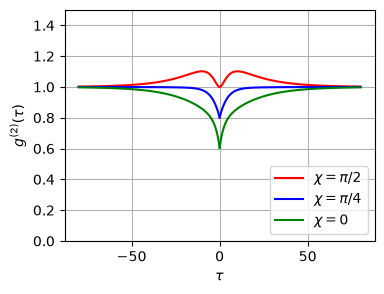

In [3]:
r12 = 0.2
times = np.linspace(0, 80, 500)

g2_0 = []
plt.figure(figsize=(4,3))

# chi = pi/2
chi = np.pi/2
H, c_ops = system_dimer(r12,theta)
rho_ss = steadystate(H,c_ops)
IR, G2, g2 = coherence2(H,c_ops,rho_ss,r12,chi,times)
plt.plot(times, np.real(g2),c='r',label=r"$\chi=\pi/2$")
plt.plot(-times, np.real(g2),c='r')
g2_0.append(g2[0])

# chi = pi/4
chi = np.pi/4
H, c_ops = system_dimer(r12,theta)
rho_ss = steadystate(H,c_ops)
IR, G2, g2 = coherence2(H,c_ops,rho_ss,r12,chi,times)
plt.plot(times, np.real(g2),c='b',label=r"$\chi=\pi/4$")
plt.plot(-times, np.real(g2),c='b')
g2_0.append(g2[0])

# chi = pi/4
chi = 0
H, c_ops = system_dimer(r12,theta)
rho_ss = steadystate(H,c_ops)
IR, G2, g2 = coherence2(H,c_ops,rho_ss,r12,chi,times)
plt.plot(times, np.real(g2),c='g',label=r"$\chi=0$")
plt.plot(-times, np.real(g2),c='g')
g2_0.append(g2[0])

plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.ylim([0,1.5])
plt.legend(loc=4)
plt.grid(True)
plt.show()

In [4]:
print("*** g^2(0): comparison bettwen QuTiP and theory ***")
print("  QuTiP    Theory")
phi = 2*np.pi*r12*np.cos(np.pi/2)
print("{0:7.4f}   {1:7.4f}".format(g2_0[0],1-phi**2/4))
phi = 2*np.pi*r12*np.cos(np.pi/4)
print("{0:7.4f}   {1:7.4f}".format(g2_0[1],1-phi**2/4))
phi = 2*np.pi*r12
print("{0:7.4f}   {1:7.4f}".format(g2_0[2],1-phi**2/4))

*** g^2(0): comparison bettwen QuTiP and theory ***
  QuTiP    Theory
 1.0000    1.0000
 0.8026    0.8026
 0.6052    0.6052


## Second-order coherence: dependence on $r_{12}$

We fix $\chi$ at $\pi/4$ and changes $r_{12}$ from $0.2$ to $0.05$.  As $r_{12}$ approaches 0, the decay rate of the $|a\rangle$ state diverges.  Hence, the correlation time also diverges. As a consequence $g^{(2)}(\tau)$ stays above 1 even at $\tau \gg 1$.  The following calculation clearly shows the trend.  We need to calculate $g^{(2)}(\tau)$ differently for $\r_{12}=0$. 

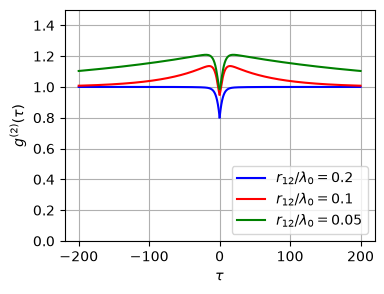

In [5]:
chi = np.pi/4
times = np.linspace(0, 200, 500)

g2_0 = []
plt.figure(figsize=(4,3))

# r12 = 0.2
r12=0.2
H, c_ops = system_dimer(r12,theta)
rho_ss = steadystate(H,c_ops)
IR, G2, g2 = coherence2(H,c_ops,rho_ss,r12,chi,times)
plt.plot(times, np.real(g2),c='b',label=r"$r_{12}/\lambda_{0}=0.2$")
plt.plot(-times, np.real(g2),c='b')
g2_0.append(g2[0])

# r12 = 0.1
r12=0.1
H, c_ops = system_dimer(r12,theta)
rho_ss = steadystate(H,c_ops)
IR, G2, g2 = coherence2(H,c_ops,rho_ss,r12,chi,times)
plt.plot(times, np.real(g2),c='r',label=r"$r_{12}/\lambda_{0}=0.1$")
plt.plot(-times, np.real(g2),c='r')
g2_0.append(g2[0])

# r12 = 0.05
r12=0.05
H, c_ops = system_dimer(r12,theta)
rho_ss = steadystate(H,c_ops)
IR, G2, g2 = coherence2(H,c_ops,rho_ss,r12,chi,times)
plt.plot(times, np.real(g2),c='g',label=r"$r_{12}/\lambda_{0}=0.05$")
plt.plot(-times, np.real(g2),c='g')
g2_0.append(g2[0])

plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.ylim([0,1.5])
plt.legend(loc=4)
plt.grid(True)
plt.show()

In [6]:
print("*** g^2(0): comparison bettwen QuTiP and theory ***")
print("  QuTiP    Theory")
r12=0.2
phi = 2*np.pi*r12*np.cos(np.pi/4)
print("{0:7.4f}   {1:7.4f}".format(g2_0[0],1-phi**2/4))
r12=0.1
phi = 2*np.pi*r12*np.cos(np.pi/4)
print("{0:7.4f}   {1:7.4f}".format(g2_0[1],1-phi**2/4))
r12=0.05
phi = 2*np.pi*r12*np.cos(np.pi/4)
print("{0:7.4f}   {1:7.4f}".format(g2_0[2],1-phi**2/4))

*** g^2(0): comparison bettwen QuTiP and theory ***
  QuTiP    Theory
 0.8026    0.8026
 0.9507    0.9507
 0.9877    0.9877


## In the case ergodicity is broken

When the ergodicity is broken, we construct a steady state manually by excluding $|a\rangle$.  See {numref}`ssec:broken-ergodicity`.

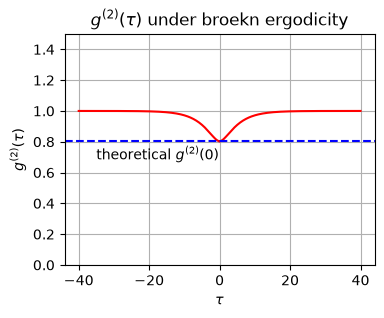

In [7]:
# Boltzmann distribution with out |a>
Z=1+np.exp(-omega0/temperature)+np.exp(omega0/temperature)
pe = np.exp(-omega0/temperature)/Z
ps = 1/Z
pg = np.exp(omega0/temperature)/Z

# steady state density
rho_ss = pe* v[0]*v[0].dag() + ps*v[1]*v[1].dag() + pg*v[3]*v[3].dag()

times = np.linspace(0, 40, 200)

chi = 0
r12=0
H, c_ops = system_dimer(r12,theta)
IR, G2, g2 = coherence2(H,c_ops,rho_ss,r12,chi,times)

q = np.exp(-omega0/temperature)
g2_0 = 1 - q/(1+q)**2

plt.figure(figsize=(4,3))
plt.title(r"$g^{(2)}(\tau)$ under broekn ergodicity")
plt.plot(times, np.real(g2),c='r')
plt.plot(-times, np.real(g2),c='r')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.ylim([0,1.5])
plt.axhline(y=g2_0,color='b',ls='--')
plt.text(-35,0.68,r"theoretical $g^{(2)}(0)$")
plt.grid(True)
plt.show()


# 